# TP FINAL REDES NEURAIS - PARTE 1

Para esse trabalho eu escolhi replicar o artigo do DistilBERT de 2019.

Clarisson H. P. Bento - 4005

## Instalação de Dependências

In [ ]:
!pip install -q --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.7 MB/s eta 0:00:00


In [ ]:
!pip install -q transformers datasets evaluate accelerate torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00


## Importação e Configuração de Hardware

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import evaluate
from torch.utils.data import DataLoader
import time

# Garante a utilização da GPU do Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executando em: {device}")

Executando em: cuda


## Download do Dataset

In [ ]:
# Baixando o dataset SST-2 do GLUE
dataset = load_dataset("nyu-mll/glue", "sst2")

val_dataset = dataset['validation']
print(f"Total de exemplos para teste: {len(val_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total de exemplos para teste: 872


 ## Tokenização

 **Observação sobre essa parte**:

 O DistilBERT original precisa de um "fine-tuning" pra realizar tarefas específicas. Para economizar algumas horas de treinamento e ir direto para os resultados da Tabela 1 do artigo, decidi utilizar os pesos de uma versão oficial já adaptada para o dataset SST-2. Que é justamente o dataset que foi utilizado no artigo.

In [ ]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

# Aplicando a transformação nos dados textuais
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_val.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

## Carregamento do Modelo DistilBERT

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)

# Colocando o modelo em modo de avaliação (desativa a atualização de pesos)
model.eval()
print("Modelo carregado com sucesso!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Modelo carregado com sucesso!


## Reprodução do Experimento e Coleta de Métricas

In [ ]:
# Carregando as métricas combinadas
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
dataloader = DataLoader(tokenized_val, batch_size=32)

print("Iniciando a inferência no SST-2...")
start_time = time.time()

with torch.no_grad():
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)

        clf_metrics.add_batch(predictions=predictions, references=labels)

execution_time = time.time() - start_time
final_scores = clf_metrics.compute()

print(f"\n--- RESULTADOS SST-2 ---")
print(f"Acurácia:  {final_scores['accuracy'] * 100:.2f}%")
print(f"F1-score:  {final_scores['f1'] * 100:.2f}%")
print(f"Precisão:  {final_scores['precision'] * 100:.2f}%")
print(f"Revocação: {final_scores['recall'] * 100:.2f}%")
print(f"Tempo de execução: {execution_time:.2f} segundos")

Iniciando a inferência no SST-2...

--- RESULTADOS SST-2 ---
Acurácia:  91.06%
F1-score:  91.37%
Precisão:  89.78%
Revocação: 93.02%
Tempo de execução: 3.76 segundos


## Fazendo o mesmo com o dataset do IMDb

In [ ]:
print("Baixando o dataset IMDb...")
imdb_dataset = load_dataset("stanfordnlp/imdb")
test_imdb = imdb_dataset['test']

# Carregando o modelo treinado para o IMDb e o tokenizador
imdb_model_name = "textattack/distilbert-base-uncased-IMDB"
imdb_tokenizer = AutoTokenizer.from_pretrained(imdb_model_name)
imdb_model = AutoModelForSequenceClassification.from_pretrained(imdb_model_name).to(device)
imdb_model.eval()

def tokenize_imdb(examples):
    return imdb_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

print("Tokenizando os dados do IMDb (Isso pode levar um minuto)...")
tokenized_imdb = test_imdb.map(tokenize_imdb, batched=True)
tokenized_imdb.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

imdb_dataloader = DataLoader(tokenized_imdb, batch_size=32)
imdb_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

print("Iniciando a inferência no IMDb...")
start_time_imdb = time.time()

with torch.no_grad():
    for batch in imdb_dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = imdb_model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)

        imdb_metrics.add_batch(predictions=predictions, references=labels)

exec_time_imdb = time.time() - start_time_imdb
imdb_scores = imdb_metrics.compute()

print(f"\n--- RESULTADOS IMDb ---")
print(f"Acurácia:  {imdb_scores['accuracy'] * 100:.2f}%")
print(f"F1-score:  {imdb_scores['f1'] * 100:.2f}%")
print(f"Precisão:  {imdb_scores['precision'] * 100:.2f}%")
print(f"Revocação: {imdb_scores['recall'] * 100:.2f}%")
print(f"Tempo de execução: {exec_time_imdb:.2f} segundos")

Baixando o dataset IMDb...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Tokenizando os dados do IMDb (Isso pode levar um minuto)...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Iniciando a inferência no IMDb...

--- RESULTADOS IMDb ---
Acurácia:  91.04%
F1-score:  91.00%
Precisão:  91.41%
Revocação: 90.61%
Tempo de execução: 185.51 segundos


# PARTE 2 - Aprimoramento e Retreinamento

In [ ]:
!pip install nlpaug nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 27.1 MB/s eta 0:00:00


## O código de Aumento de Dados (Data Augmentation)

In [ ]:
import nlpaug.augmenter.word as naw
import nltk
from datasets import load_dataset

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Carregando o dataset SST-2 original...")
dataset = load_dataset("nyu-mll/glue", "sst2")
train_dataset = dataset['train']

aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.10)

def augment_text(batch):
    augmented_sentences = []
    for text in batch['sentence']:
        augmented_text = aug.augment(text)

        if isinstance(augmented_text, list):
            augmented_text = augmented_text[0]

        augmented_sentences.append(augmented_text)

    return {"sentence": augmented_sentences}

print("Aplicando Data Augmentation...")
augmented_train_dataset = train_dataset.map(augment_text, batched=True, batch_size=128)

print(f"Dataset original: {len(train_dataset)} exemplos.")
print(f"Dataset aumentado gerado com sucesso!")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Carregando o dataset SST-2 original...


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Aplicando Data Augmentation... (Isso pode levar alguns minutos)


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Dataset original: 67349 exemplos.
Dataset aumentado gerado com sucesso!


## Verificando o resultado

In [ ]:
# Print de exemplo para ver a alteração
print("Original: ", train_dataset[5]['sentence'])
print("Aumentado:", augmented_train_dataset[5]['sentence'])

Original:  that 's far too tragic to merit such superficial treatment 
Aumentado: that ' s far too tragical to deserve such superficial treatment


In [ ]:
print("Procurando frases alteradas...\n")
alterados_encontrados = 0

for i in range(len(train_dataset)):
    original = train_dataset[i]['sentence']
    aumentado = augmented_train_dataset[i]['sentence']

    # Verifica se houve substituição de sinônimo
    if original != aumentado:
        print(f"--- Índice {i} ---")
        print(f"Original:  {original}")
        print(f"Aumentado: {aumentado}\n")
        alterados_encontrados += 1

    # Para o laço depois de achar X exemplos
    if alterados_encontrados == 10:
        break

Procurando frases alteradas...

--- Índice 0 ---
Original:  hide new secretions from the parental units 
Aumentado: hide new secretions from the parental units

--- Índice 1 ---
Original:  contains no wit , only labored gags 
Aumentado: contains no wit, only labored laugh

--- Índice 2 ---
Original:  that loves its characters and communicates something rather beautiful about human nature 
Aumentado: that do it its characters and communicates something rather beautiful about human nature

--- Índice 3 ---
Original:  remains utterly satisfied to remain the same throughout 
Aumentado: remains utterly satisfied to remain the like throughout

--- Índice 4 ---
Original:  on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
Aumentado: on the worst revenge - of - the - nerds clichés the film producer could dredge up

--- Índice 5 ---
Original:  that 's far too tragic to merit such superficial treatment 
Aumentado: that ' s far too tragical to deserve such superficial treat

## Retreinando pro SST-2 (Descartado)
Foi a primeira tentativa e os resultados não foram os esperados, então avancei para outras estratégias, que correspondem a versão com arquitetura customizada que está no final desse documento.

In [ ]:
import evaluate
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

print("Baixando tokenizador e o modelo base (sem fine-tuning)...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

print("Tokenizando o dataset aumentado (Treino)...")
tokenized_train = augmented_train_dataset.map(tokenize_function, batched=True)

print("Tokenizando o dataset original (Validação)...")
tokenized_val = dataset['validation'].map(tokenize_function, batched=True)

clf_metrics = evaluate.combine(["accuracy", "f1"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return clf_metrics.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./resultados_tpf02",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    num_train_epochs=3,
    lr_scheduler_type="cosine_with_restarts",
    warmup_steps=500,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Iniciando o treinamento!")
trainer.train()

Baixando tokenizador e o modelo base (sem fine-tuning)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizando o dataset aumentado (Treino)...
Tokenizando o dataset original (Validação)...


Map:   0%|          | 0/872 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6315, training_loss=0.19790047368452082, metrics={'train_runtime': 2461.82, 'train_samples_per_second': 82.072, 'train_steps_per_second': 2.565, 'total_flos': 6691160124062208.0, 'train_loss': 0.19790047368452082, 'epoch': 3.0})

### Gráfico do treinamento para o SST-2

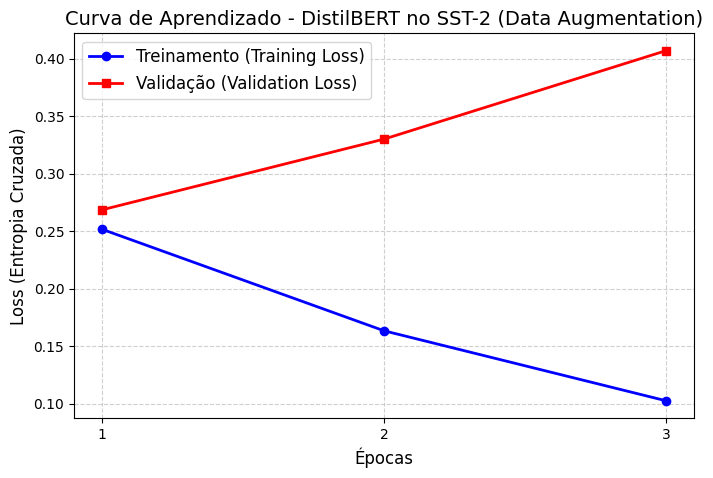

In [ ]:
import matplotlib.pyplot as plt

# Anotando os dados manualmente porque as variáveis somem quando a T4 desconecta
epochs = [1, 2, 3]
train_loss = [0.251480, 0.163292, 0.102483]
val_loss = [0.268481, 0.329927, 0.406772]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Treinamento (Training Loss)', marker='o', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validação (Validation Loss)', marker='s', color='red', linewidth=2)

plt.title('Curva de Aprendizado - DistilBERT no SST-2 (Data Augmentation)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss (Entropia Cruzada)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.savefig('loss_curve_sst2.png', dpi=300, bbox_inches='tight')
plt.show()

## Retreinamento pro IMDB (Descartado)
Acabei descartando isso aqui e não mencionei nos resultados

In [ ]:
import nlpaug.augmenter.word as naw
import nltk
from datasets import load_dataset
import evaluate
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

print("Carregando o IMDb...")
imdb_dataset = load_dataset("stanfordnlp/imdb")
train_imdb = imdb_dataset['train']
test_imdb = imdb_dataset['test']

# Data Augmentation
aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.10)

def augment_imdb(batch):
    augmented_sentences = []

    for text in batch['text']:
        augmented_text = aug.augment(text)
        if isinstance(augmented_text, list):
            augmented_text = augmented_text[0]
        augmented_sentences.append(augmented_text)
    return {"text": augmented_sentences}

print("Iniciando Data Augmentation no IMDb")
# Aplicando apenas no treino para não poluir o teste
augmented_train_imdb = train_imdb.map(augment_imdb, batched=True, batch_size=128)

# Tokenização
# Carregamos a versão já ajustada para o IMDb para ser nossa nova linha de base
print("Baixando tokenizador e o modelo base do IMDb...")
model_name = "textattack/distilbert-base-uncased-IMDB"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_imdb(examples):
    # Textos longos: max_length aumentado para 256
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

print("Tokenizando os datasets...")
tokenized_train = augmented_train_imdb.map(tokenize_imdb, batched=True)
tokenized_test = test_imdb.map(tokenize_imdb, batched=True)

clf_metrics = evaluate.combine(["accuracy", "f1"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return clf_metrics.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./resultados_imdb_madrugada",
    eval_strategy="epoch",
    save_strategy="epoch",          # Salva um checkpoint no final de cada época
    learning_rate=2e-5,
    per_device_train_batch_size=16, # Reduzido pela metade para caber textos longos na VRAM
    gradient_accumulation_steps=2,  # Acumula gradientes para simular lote de 32
    num_train_epochs=3,
    lr_scheduler_type="cosine_with_restarts",
    warmup_steps=500,
    weight_decay=0.01,
    fp16=True,                      # Ativa precisão mista (16-bits) para acelerar a GPU T4
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Iniciando o treinamento para o dataset do IMDb")
trainer.train()

Carregando o IMDb...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.196518,0.300864,0.900880,0.901978
2,0.140454,0.439948,0.907920,0.906960
3,0.082155,0.513598,0.905120,0.906059


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2346, training_loss=0.1426063132712908, metrics={'train_runtime': 806.2435, 'train_samples_per_second': 93.024, 'train_steps_per_second': 2.91, 'total_flos': 4967527449600000.0, 'train_loss': 0.1426063132712908, 'epoch': 3.0})

### Gráfico do treinamento pro IMDB

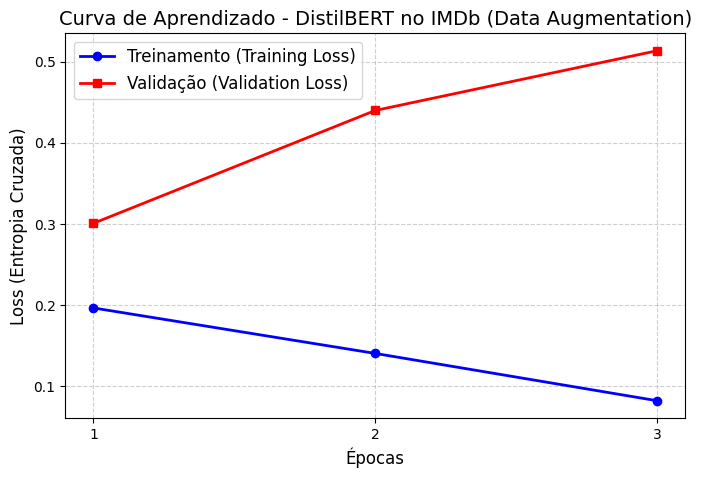

In [ ]:
import matplotlib.pyplot as plt

# Anotando os dados manualmente porque as variáveis somem quando a T4 desconecta
epochs = [1, 2, 3]
train_loss = [0.196518, 0.140454, 0.082155]
val_loss = [0.300864, 0.439948, 0.513598]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Treinamento (Training Loss)', marker='o', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validação (Validation Loss)', marker='s', color='red', linewidth=2)

plt.title('Curva de Aprendizado - DistilBERT no IMDb (Data Augmentation)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss (Entropia Cruzada)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.savefig('loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Experimento Final: Arquitetura Customizada (MLP + Dropout) e Early Stopping

## Definição da Função de Métricas

In [ ]:
import evaluate
import numpy as np

clf_metrics = evaluate.combine(["accuracy", "f1"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return clf_metrics.compute(predictions=predictions, references=labels)

## Célula de Tokenização

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

print("Tokenizando o dataset aumentado (Treino)...")
tokenized_train = augmented_train_dataset.map(tokenize_function, batched=True)

print("Tokenizando o dataset original (Validação)...")
tokenized_val = dataset['validation'].map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizando o dataset aumentado (Treino)...


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Tokenizando o dataset original (Validação)...


Map:   0%|          | 0/872 [00:00<?, ? examples/s]

## Treinando o Frankstein em cima do SST-2

In [ ]:
import torch
from torch import nn
import evaluate
import numpy as np
from transformers import AutoModel, TrainingArguments, Trainer, EarlyStoppingCallback

# 1 - Definindo uma arquitetura customizada
class DistilBertComMLPDropout(nn.Module):
    def __init__(self, num_labels=2):
        super().__init__()
        # Carrega apenas o corpo do modelo pré-treinado
        self.distilbert = AutoModel.from_pretrained("distilbert-base-uncased")

        # Cabeça de classificação customizada (MLP com Dropout)
        self.pre_classifier = nn.Linear(768, 768)
        self.relu = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.4) # Dropout agressivo de 40%
        self.camada_oculta = nn.Linear(768, 256)
        self.dropout_2 = nn.Dropout(0.2)
        self.classifier = nn.Linear(256, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Passa pelo corpo do Transformer
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = outputs[0][:, 0] # Pega o token [CLS]

        # Passa pela nossa MLP customizada
        x = self.pre_classifier(hidden_state)
        x = self.relu(x)
        x = self.dropout_1(x)
        x = self.camada_oculta(x)
        x = self.relu(x)
        x = self.dropout_2(x)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, 2), labels.view(-1))

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

print("Inicializando o modelo com arquitetura customizada...")
model_customizado = DistilBertComMLPDropout(num_labels=2)

# 2 - Configurando o treinamento com Early Stopping e Cosine Annealing
training_args_custom = TrainingArguments(
    output_dir="./resultados_tpf02_custom",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    num_train_epochs=5, # Aumentamos para 5 épocas
    lr_scheduler_type="cosine_with_restarts",
    warmup_steps=500,
    weight_decay=0.01,
    load_best_model_at_end=True, # Detalho pro Early Stopping funcionar
    metric_for_best_model="accuracy",
)

# 3 - Amarrando tudo
trainer_custom = Trainer(
    model=model_customizado,
    args=training_args_custom,
    train_dataset=tokenized_train, # Reutilizamos o dataset aumentado do WordNet
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics, # Reutilizamos a métrica instanciada anteriormente
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Para o treino se não melhorar após 2 épocas
)

print("Iniciando o treinamento final")
trainer_custom.train()

Inicializando o modelo com arquitetura customizada...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando o treinamento final! (Isso deve levar de 15 a 20 minutos)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.252834,0.281192,0.895642,0.898776
2,0.176178,0.306563,0.897936,0.903156
3,0.112585,0.381799,0.901376,0.904018
4,0.070573,0.474478,0.892202,0.895556
5,0.055395,0.533264,0.889908,0.894737


TrainOutput(global_step=10525, training_loss=0.14919884779107825, metrics={'train_runtime': 3704.6251, 'train_samples_per_second': 90.899, 'train_steps_per_second': 2.841, 'total_flos': 0.0, 'train_loss': 0.14919884779107825, 'epoch': 5.0})

### Gráfico do treinamento

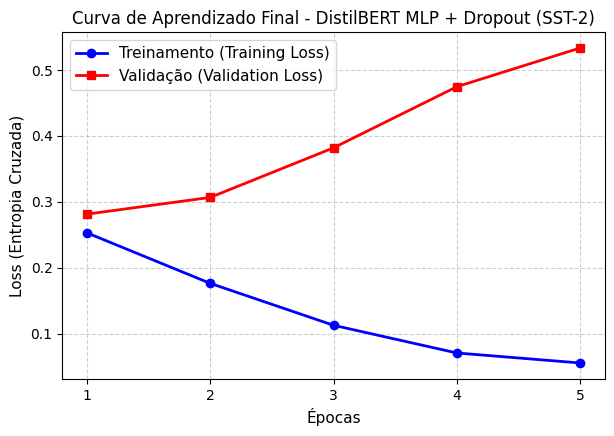

In [ ]:
import matplotlib.pyplot as plt

# Anotando os dados manualmente porque as variáveis somem quando a T4 desconecta
epochs = [1, 2, 3, 4, 5]
train_loss = [0.252834, 0.176178, 0.112585, 0.070573, 0.055395]
val_loss = [0.281192, 0.306563, 0.381799, 0.474478, 0.533264]

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, train_loss, label='Treinamento (Training Loss)', marker='o', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validação (Validation Loss)', marker='s', color='red', linewidth=2)

plt.title('Curva de Aprendizado Final - DistilBERT MLP + Dropout (SST-2)', fontsize=12)
plt.xlabel('Épocas', fontsize=11)
plt.ylabel('Loss (Entropia Cruzada)', fontsize=11)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.savefig('final_loss_curve_sst2.png', dpi=300, bbox_inches='tight')
plt.show()